In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

### Step 1: Read

In [2]:
filename = 'paysim_transactions.csv.gz' 

# load the file into a DataFrame 
df = pd.read_csv(filename)

In [45]:
data = df.copy()

# sort by step
data = data.sort_values(by='step', kind = 'stable')

# add history features 
# group by nameOrig and apply cumcount()
data['prior_txn_count'] = data.groupby(by='nameOrig').cumcount()

# total amount this sender moved BEFORE this transaction   
data['prior_amount_sum'] = data.groupby(by='nameOrig')['amount'].cumsum() - data['amount']

# sender's average past transaction amount; NaN for account's first transaction 
data['prior_amount_mean'] = data['prior_amount_sum'] / data['prior_txn_count']

# how many times larger this transaction is than the sender's usual amount 
data['amount_ratio'] = data['amount'] / data['prior_amount_mean'] 

########################################################

# only TRANSFER and CASH_OUT rows of df
filtered_data = data[data['action'].isin(['TRANSFER','CASH_OUT'])].copy()

filtered_data['day'] = filtered_data['step']//24

########################################################
# prepare the inputs 
transfer_mask = filtered_data['action'] == 'TRANSFER'

filtered_data['is_transfer'] = transfer_mask.astype(int)

########################################################
# lets create the train and test dataset 
train_mask = filtered_data['day'] < 24 
test_mask = filtered_data['day'] >= 24

train = filtered_data[train_mask]
test = filtered_data[test_mask]

# build X and y for train and test 
features = ['amount', 'is_transfer', 'prior_txn_count', 'amount_ratio']

X_train = train[features]
y_train = train['isFraud']

X_test = test[features]
y_test = test['isFraud']


### Step 2: clean the inputs for logistic regression 

In [46]:
# the missing values 

X_train.isna().sum(), X_test.isna().sum()

### only amount_ratio has na -- lets fill that with 1, which means nothing 
# unusual compared to this account's history 

(amount               0
 is_transfer          0
 prior_txn_count      0
 amount_ratio       915
 dtype: int64,
 amount               0
 is_transfer          0
 prior_txn_count      0
 amount_ratio       126
 dtype: int64)

In [47]:
X_train = X_train.fillna(1)
X_test = X_test.fillna(1)

In [48]:
X_train.isna().sum(), X_test.isna().sum()

(amount             0
 is_transfer        0
 prior_txn_count    0
 amount_ratio       0
 dtype: int64,
 amount             0
 is_transfer        0
 prior_txn_count    0
 amount_ratio       0
 dtype: int64)

In [49]:
X_train.describe()

,amount,is_transfer,prior_txn_count,amount_ratio
count,9.901630e+05,990163.000000,990163.000000,990163.000000
mean,2.825594e+05,0.200274,2679.450976,2.242333
std,5.490707e+05,0.400206,12965.659081,4.597033
min,1.990000e+00,0.000000,0.000000,0.000015
25%,8.954924e+04,0.000000,63.000000,0.683181
50%,1.400043e+05,0.000000,130.000000,1.093299
75%,2.091735e+05,0.000000,254.000000,1.729169
max,1.768405e+07,1.000000,105521.000000,732.152109


### Lets fix the skewed scales. 3/4 features are extremly skewed:
- amount: from a few dollars to tens of millions
- prior_txn_count: median around 100, but some accounts have thousand
- amount_ratio: mostly small, with a long tail into the hundreds

In [50]:
ls = ['amount', 'prior_txn_count', 'amount_ratio'] 

for i in ls:
    X_train[i] = np.log1p(X_train[i].copy())
    X_test[i] = np.log1p(X_test[i].copy())

In [51]:
X_train.describe()

,amount,is_transfer,prior_txn_count,amount_ratio
count,990163.000000,990163.000000,990163.000000,990163.000000
mean,11.899047,0.200274,5.042108,0.886073
std,1.049400,0.400206,1.576768,0.616217
min,1.095273,0.000000,0.000000,0.000015
25%,11.402555,0.000000,4.158883,0.520686
50%,11.849436,0.000000,4.875197,0.738741
75%,12.250924,0.000000,5.541264,1.003997
max,16.688174,1.000000,11.566675,6.597353


In [52]:
### Put the features on the same scale 

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# after fitting on train, apply the same scaler to X_test with .transform 
X_test_scaled = scaler.transform(X_test)

# check means and standard deviations 
print (X_train_scaled.mean(axis=0))
print (X_train_scaled.std(axis=0))

[1.03598734e-15 7.32671422e-17 2.83825858e-16 3.65115788e-17]
[1. 1. 1. 1.]


In [54]:
print (X_test_scaled.mean(axis=0))
print (X_test_scaled.std(axis=0))
# means and standard deviations are closer to 0 and 1, but not exact because it was scaled using the training stats

[-0.12040892 -0.02445955  0.44580014 -0.26682386]
[0.9517515  0.98120576 0.9750747  0.83066186]


#### Step 3: Train first model 

In [55]:
from sklearn.linear_model import LogisticRegression

# initiate the model 
model = LogisticRegression(class_weight='balanced', max_iter=1000)

# fit it 
model.fit(X_train_scaled, y_train)

# check coefficients 
print("Coefficients:", model.coef_)       # Internal weights
print("Intercept:", model.intercept_)   # Bias term

/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


Coefficients: [[ 0.30930203 -0.16241786 -3.30050547  2.27176556]]
Intercept: [-6.66974651]


In [57]:
np.isfinite(X_test_scaled).all()

np.True_

amount -- positive --> large amount lean toward fraud, but only mildly 
is_transfer -- negative --> slightly favors cash-outs
prior_txn_count -- negative --> Less history means much more likely to be fraud 
amount_ratio -- positive -- unusual amounts for the sender mean fraud 

In [67]:
# evalulate on the test set 

y_pred = model.predict(X_test_scaled)

# calculate recall: predicted fraud + actual fraud / (all fraud)
recall = ((y_pred == 1) & (y_test == 1)).sum() / (y_test == 1).sum()

# false positive rate: predicted fraud + actual legit / (all legit) 
fpr = ((y_pred == 1) & (y_test == 0)).sum() / (y_test == 0).sum()

print (recall, fpr)

0.9642857142857143 0.006726457399103139


/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# Does the model catch more fraud than the rules? 

- rules: yes/no
- model: gives a probability for each transaction (risk score) 

In [78]:
# fraud probability for every training transaction
train_proba = model.predict_proba(X_train_scaled)[:,1]

# keep only the scores of legit transactions 
legit_train_scores = train_proba[(y_train == 0).values]

# find threshold where model flags 1.04% of legit training transactions 
cutoff = np.quantile(legit_train_scores, 1-0.0104)

print(cutoff)

'''
higher cutoff flags fewer legit transactions 
'''

0.9522687448330945


/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [79]:
# what fraction of legit_train_scores is AT or above the cutoff?
(legit_train_scores >= cutoff).mean()

np.float64(0.010400921290899218)

In [89]:
# test probabilities 
test_proba = model.predict_proba(X_test_scaled)[:,1]

# flag each transactions with a score at or above the cutoff 
flags = test_proba >= cutoff

/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [91]:
# compute the recall and false positive rate (compared wiht rules' recall = 96% and fpr = 0.62 %) 
# calculate recall: predicted fraud + actual fraud / (all fraud)
model_recall = ((flags) & (y_test == 1)).sum() / (y_test == 1).sum()

# false positive rate: predicted fraud + actual legit / (all legit) 
model_fpr = ((flags) & (y_test == 0)).sum() / (y_test == 0).sum()

In [93]:
print (model_recall, model_fpr)

0.7658730158730159 0.001657243127315266


Both models were set to flag 1.04% of legit transactions in training, but on test, they ended up in different places. The rules' FPR fell to 0.62%, and the model's fell further to 0.17%. Same cals, but different behavior on the new data. 

- Rules catch more fraud (higher recall: 96% vs. 77%)
- Model raises about 4x fewer false alarms (0.17% vs. 0.62%)

In [94]:
from sklearn.metrics import RocCurveDisplay, roc_curve

In [95]:
fpr, tpr, thresholds = roc_curve(y_test, test_proba)

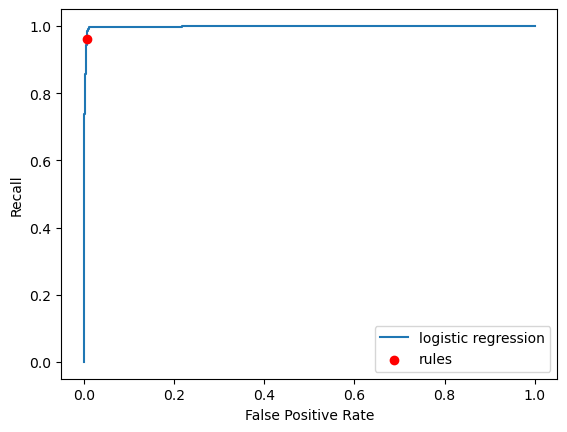

In [103]:
plt.plot(fpr, tpr, label = 'logistic regression')
plt.scatter(0.0062, 0.96, color = 'red', label = 'rules', zorder =3)
plt.xlabel("False Positive Rate")
plt.ylabel("Recall")
plt.legend()
plt.show()


(0.86, 1.0)

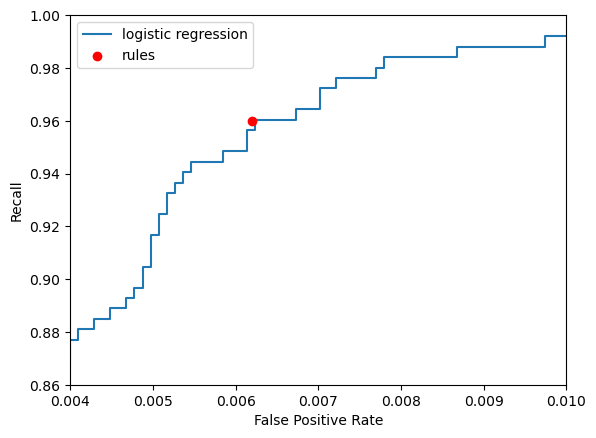

In [113]:
plt.plot(fpr, tpr, label = 'logistic regression')
plt.scatter(0.0062, 0.96, color = 'red', label = 'rules', zorder =3)
plt.xlabel("False Positive Rate")
plt.ylabel("Recall")
plt.legend()
plt.xlim([0.004,0.01])
plt.ylim([0.86,1.0])

#plt.xscale('log')

The logistic regression ROC curve passes through the rules' operating point; with four features, the linear model matches but doesn't beat the rules

In [126]:
## XGBoost 

from xgboost import XGBClassifier

X_train_raw = train[features] 
X_test_raw = test[features]


spw = (y_train == 0).sum() / (y_train == 1).sum()
print (spw)

886.2428315412186


In [127]:

xgb = XGBClassifier(
    n_estimators = 300,  # number of trees 
    max_depth = 4,       # how many questions each tree can ask 
    learning_rate = 0.1, # how much each tree corrects the previous ones
    scale_pos_weight = spw, 
    eval_metric = 'aucpr'
)

xgb.fit(X_train_raw, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [123]:
#fraud probability for every training transaction
xgb_train_proba = xgb.predict_proba(X_train_raw)[:,1]

# keep only the scores of legit transactions 
legit_xgb_train_scores = xgb_train_proba[(y_train == 0).values]

# find threshold where model flags 1.04% of legit training transactions 
xgb_cutoff = np.quantile(legit_xgb_train_scores, 1-0.0104)

print(xgb_cutoff)

0.6715421


In [128]:
# test probabilities 
xgb_test_proba = xgb.predict_proba(X_test_raw)[:,1]

# flag each transactions with a score at or above the cutoff 
xgb_flags = xgb_test_proba >= xgb_cutoff

In [132]:
xgb_recall = ((xgb_flags) & (y_test == 1)).sum() / (y_test == 1).sum()

xgb_fpr = ((xgb_flags) & (y_test == 0)).sum() / (y_test == 0).sum()

print (xgb_recall, xgb_fpr)

0.8968253968253969 0.004386820042893352


In [133]:
xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(y_test, xgb_test_proba)

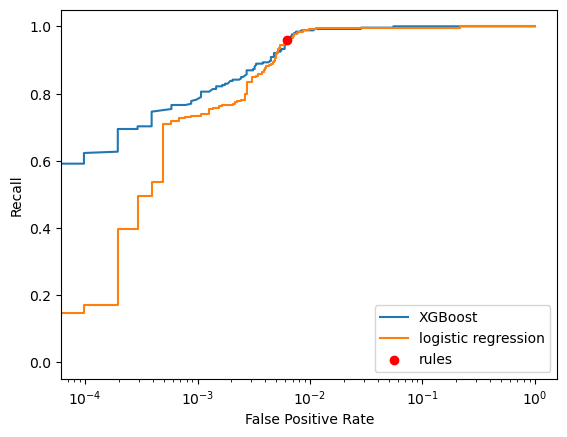

In [139]:
plt.plot(xgb_fpr, xgb_tpr, label = 'XGBoost')
plt.plot(fpr, tpr, label = 'logistic regression')
plt.scatter(0.0062, 0.96, color = 'red', label = 'rules', zorder =3)
plt.xlabel("False Positive Rate")
plt.ylabel("Recall")
plt.legend()
#plt.xlim([0.004,0.01])
#plt.ylim([0.86,1.0])

plt.xscale('log')

In [143]:
tpr[fpr <= 0.002].max(), xgb_tpr[xgb_fpr <= 0.002].max(), xgb_tpr[xgb_fpr <= 0.0062].max()

(np.float64(0.7658730158730159), np.float64(0.8373015873015873))

np.float64(0.9603174603174603)

There were a total of three methods that I tested: 1) Rules; 2) Logistic Regression (LR); 3) XGBoost. Both LR and XGBoost used the same four features: amount, is_transfer, prior_txn_count, and amount_ratio. Logistic regression used log-transformed (for the three skewed features) and standardized inputs, with class weighting. XGBoost used the raw features, with NaN handled natively, and scale_pos_weight. 

Each model's cutoff was set on the training data set to match the rules' false alarm budget (1.04% of legit transactions) and then evaluated on the testing data set. The two models ended up at different test false positive rates, with LR having 0.17% and XGBoost having a FPR of 0.44%. 

The table below summarizes the results for all three methods. 


| Method | Recall (test) | FPR (test) |
|---|---|---|
| Rules | 96.0% | 0.62% |
| Logistic regression | 76.6% | 0.17% |
| XGBoost | 89.7% | 0.44% |


Since the models ended up at different FPRs, I compared full ROC curves and each model's recall at a fixed FPR. The table below summarizes the comparison of XGBoost with each method:

| Comparison | Result |
|---|---|
| XGBoost vs. Rules, at 0.62% FPR | **Tie** (96.0% vs. 96.0%) | 
| XGBoost vs. LR  at 0.2% FPR | **XGBoost better** (83.0% vs. 76.6%), modest but likely real|

XGBoost matches the rules at their operating point, but doesn't beat them with these four features. The models' advantage is flexibility: the rules give one operating point, while a model's cutoff can be set to any false alarm budget. In addition, XGBoost outperforms LR at low false alarm rates, likely because it captures interactions between features.


Next, I'll add a recipient-history feature, showing how many times the recipient account has received money before.

In [161]:
data = df.copy()
data = data.sort_values(by='step', kind='stable')

# history 
data['prior_txn_count'] = data.groupby('nameOrig').cumcount()

data['prior_amount_sum'] = data.groupby('nameOrig')['amount'].cumsum() - data['amount']

data['prior_amount_mean'] = data['prior_amount_sum'] / data['prior_txn_count']

data['amount_ratio'] = data['amount'] / data['prior_amount_mean']

data['dest_prior_recv_count'] = data.groupby('nameDest').cumcount()


### filter 
filtered_data = data[data['action'].isin(['TRANSFER', 'CASH_OUT'])].copy()
filtered_data['day'] = filtered_data['step'] // 24
filtered_data['is_transfer'] = (filtered_data['action'] == 'TRANSFER').astype(int)


train = filtered_data[filtered_data['day'] < 24].copy()
test  = filtered_data[filtered_data['day'] >= 24].copy()

transfer_train = train[train['action'] == 'TRANSFER']

flagged = transfer_train['dest_prior_recv_count'] == 0
fraud   = transfer_train['isFraud'] == 1

recall    = (flagged & fraud).sum() / fraud.sum()
precision = (flagged & fraud).sum() / flagged.sum()
print(recall, precision)

1.0 0.02714271816324545


In [162]:
# build X and y for train and test 
features = ['amount', 'is_transfer', 'prior_txn_count', 'amount_ratio', 'dest_prior_recv_count']

X_train = train[features]
y_train = train['isFraud']

X_test = test[features]
y_test = test['isFraud']

In [163]:
X_train.isna().sum(), X_test.isna().sum()


(amount                     0
 is_transfer                0
 prior_txn_count            0
 amount_ratio             915
 dest_prior_recv_count      0
 dtype: int64,
 amount                     0
 is_transfer                0
 prior_txn_count            0
 amount_ratio             126
 dest_prior_recv_count      0
 dtype: int64)

In [164]:
X_train = X_train.fillna(1)
X_test = X_test.fillna(1)

In [165]:
ls = ['amount', 'prior_txn_count', 'amount_ratio', 'dest_prior_recv_count'] 

for i in ls:
    X_train[i] = np.log1p(X_train[i].copy())
    X_test[i] = np.log1p(X_test[i].copy())

In [166]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# after fitting on train, apply the same scaler to X_test with .transform 
X_test_scaled = scaler.transform(X_test)

# check means and standard deviations 
print (X_train_scaled.mean(axis=0))
print (X_train_scaled.std(axis=0))

[1.03598734e-15 7.32671422e-17 2.83825858e-16 3.65115788e-17
 5.54792292e-16]
[1. 1. 1. 1. 1.]


In [167]:
print (X_test_scaled.mean(axis=0))
print (X_test_scaled.std(axis=0))
# means and standard deviations are closer to 0 and 1, but not exact because it was scaled using the training stats

[-0.12040892 -0.02445955  0.44580014 -0.26682386  0.68553093]
[0.9517515  0.98120576 0.9750747  0.83066186 0.8683715 ]


In [168]:
from sklearn.linear_model import LogisticRegression

# initiate the model 
model = LogisticRegression(class_weight='balanced', max_iter=1000)

# fit it 
model.fit(X_train_scaled, y_train)

# check coefficients 
print("Coefficients:", model.coef_)       # Internal weights
print("Intercept:", model.intercept_)   # Bias term

/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


Coefficients: [[ 1.01258195 -2.69436475 -4.78821377  2.19529207 -3.46031482]]
Intercept: [-11.81708137]


In [169]:
# evalulate on the test set 
y_pred = model.predict(X_test_scaled)

# calculate recall: predicted fraud + actual fraud / (all fraud)
recall = ((y_pred == 1) & (y_test == 1)).sum() / (y_test == 1).sum()

# false positive rate: predicted fraud + actual legit / (all legit) 
fpr = ((y_pred == 1) & (y_test == 0)).sum() / (y_test == 0).sum()

print (recall, fpr)

0.9880952380952381 0.0004874244492103724


/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [170]:
# fraud probability for every training transaction
train_proba = model.predict_proba(X_train_scaled)[:,1]

# keep only the scores of legit transactions 
legit_train_scores = train_proba[(y_train == 0).values]

# find threshold where model flags 1.04% of legit training transactions 
cutoff = np.quantile(legit_train_scores, 1-0.0104)

print(cutoff)

0.8835767267649196


/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [171]:
# test probabilities 
test_proba = model.predict_proba(X_test_scaled)[:,1]

# flag each transactions with a score at or above the cutoff 
flags = test_proba >= cutoff

/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pachia/ENTER/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [172]:
# compute the recall and false positive rate (compared wiht rules' recall = 96% and fpr = 0.62 %) 
# calculate recall: predicted fraud + actual fraud / (all fraud)
model_recall = ((flags) & (y_test == 1)).sum() / (y_test == 1).sum()

# false positive rate: predicted fraud + actual legit / (all legit) 
model_fpr = ((flags) & (y_test == 0)).sum() / (y_test == 0).sum()

print (model_recall, model_fpr)

0.9166666666666666 9.748488984207447e-05


In [173]:
fpr, tpr, thresholds = roc_curve(y_test, test_proba)

(0.004, 0.01)

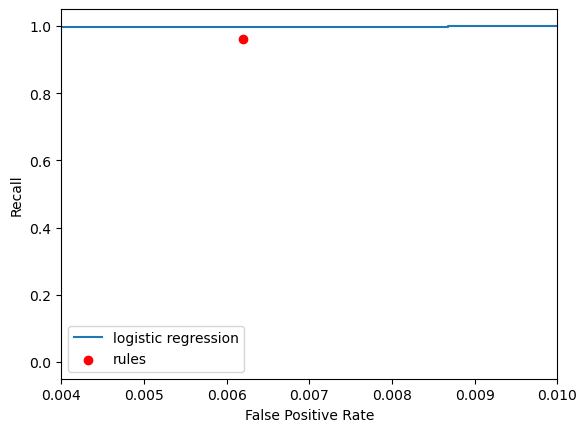

In [176]:
plt.plot(fpr, tpr, label = 'logistic regression')
plt.scatter(0.0062, 0.96, color = 'red', label = 'rules', zorder =3)
plt.xlabel("False Positive Rate")
plt.ylabel("Recall")
plt.legend()
plt.xlim([0.004,0.01])
#plt.ylim([0.86,1.0])

#plt.xscale('log')

In [177]:
tpr[fpr <= 0.0062].max(), tpr[fpr <=0.002].max()

# the moel clearly beats the rules: 9 more fraud casses caught at the same false alarm budget 

(np.float64(0.996031746031746), np.float64(0.996031746031746))

In [178]:
# redo this with XGBoost 
X_train_raw = train[features] 
X_test_raw = test[features]


spw = (y_train == 0).sum() / (y_train == 1).sum()
print (spw)

886.2428315412186


In [179]:

xgb = XGBClassifier(
    n_estimators = 300,  # number of trees 
    max_depth = 4,       # how many questions each tree can ask 
    learning_rate = 0.1, # how much each tree corrects the previous ones
    scale_pos_weight = spw, 
    eval_metric = 'aucpr'
)

xgb.fit(X_train_raw, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [180]:
#fraud probability for every training transaction
xgb_train_proba = xgb.predict_proba(X_train_raw)[:,1]

# keep only the scores of legit transactions 
legit_xgb_train_scores = xgb_train_proba[(y_train == 0).values]

# find threshold where model flags 1.04% of legit training transactions 
xgb_cutoff = np.quantile(legit_xgb_train_scores, 1-0.0104)

print(xgb_cutoff)

0.0005019502


In [181]:
# test probabilities 
xgb_test_proba = xgb.predict_proba(X_test_raw)[:,1]

# flag each transactions with a score at or above the cutoff 
xgb_flags = xgb_test_proba >= xgb_cutoff

In [182]:
xgb_recall = ((xgb_flags) & (y_test == 1)).sum() / (y_test == 1).sum()

xgb_fpr = ((xgb_flags) & (y_test == 0)).sum() / (y_test == 0).sum()

print (xgb_recall, xgb_fpr)

0.9920634920634921 9.748488984207447e-05


In [183]:
xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(y_test, xgb_test_proba)

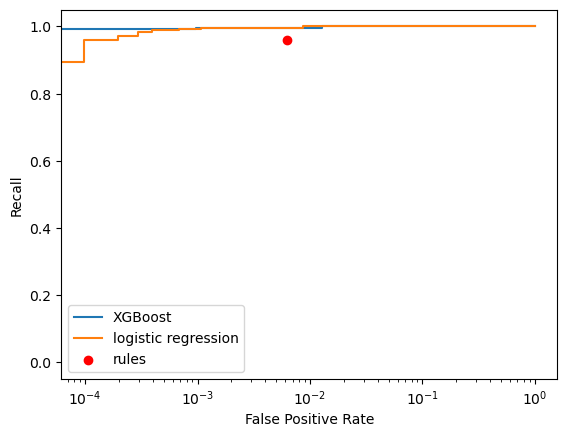

In [184]:
plt.plot(xgb_fpr, xgb_tpr, label = 'XGBoost')
plt.plot(fpr, tpr, label = 'logistic regression')
plt.scatter(0.0062, 0.96, color = 'red', label = 'rules', zorder =3)
plt.xlabel("False Positive Rate")
plt.ylabel("Recall")
plt.legend()
#plt.xlim([0.004,0.01])
#plt.ylim([0.86,1.0])

plt.xscale('log')

In [185]:
xgb_tpr[xgb_fpr <= 0.002].max(), xgb_tpr[xgb_fpr <= 0.0062].max()

(np.float64(0.996031746031746), np.float64(0.996031746031746))

In this new set of models, I added a new feature using the column ```dest_prior_recv_count``` , which counts how many times the recipient had recieved money before. Used alone as a rule on training transfers (flag if the recipient has never received money), it had 100% recall and 2.7% precision. I then retrained both model with the same procedure as before. 

Here is the resulting table comparing the models with 4 vs 5 features: 

| Method | Recall at FPR <=0.62% | Recall at FPR <=0.2% |
|---|---|---|
| Rules | 96.0% | n/a (single operating point) |
| LR, 4 features | 96.0% | 76.6% |
| XGBoost, 4 features | 96.0% | 83.0% |
| LR, 5 features | 99.6% | 99.6% |
| XGBoost, 5 features | 99.6% | 99.2% |



The recipient feature made the difference: both models jumped from matching the rules (96.0%) to clearly beating them (99.6%) at the same false alarm budget. With five features, LR and XGBoost are tied; the difference is one fraud case, well within the noise. When the features are this informative, the simpler model performs as well as the complex one, and LR is easier to explain to a fraud team or regulator.

**Caveat**: in PaySim, every mule account is brand new and receives money exactly once, which makes the recipient signal unusually clean. Real mule accounts are often older or reused, so the gain would likely be smaller on real data.

### SHAP 

In [187]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test_raw)

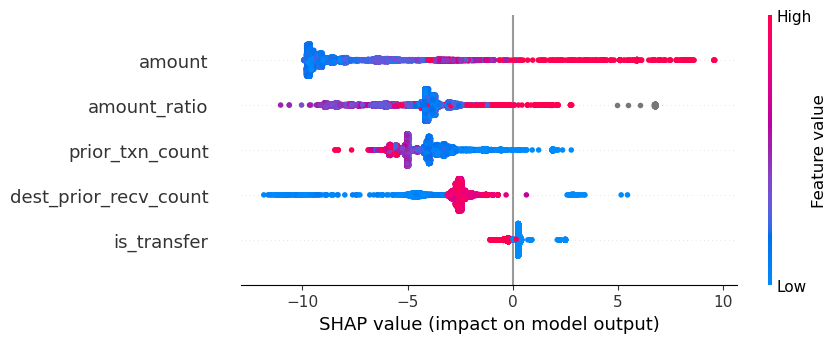

In [188]:
# which features matter the most overall 
shap.plots.beeswarm(shap_values)

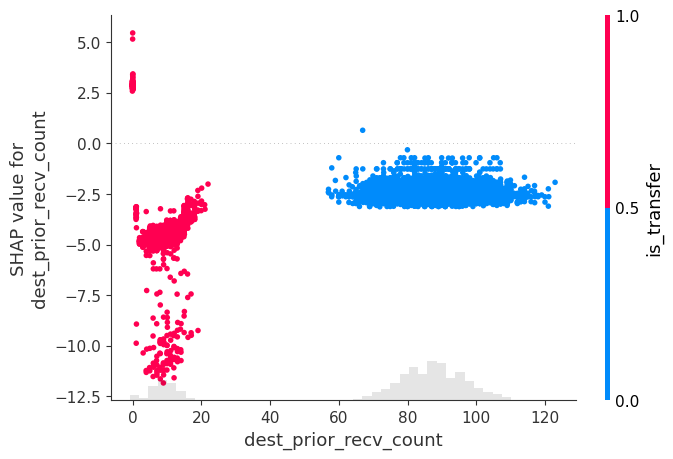

In [189]:
shap.plots.scatter(shap_values[:, 'dest_prior_recv_count'], color=shap_values[:, 'is_transfer'])

In [190]:
caught = np.where(xgb_flags & (y_test == 1).values)[0]
i = caught[0]          # position of the first caught fraud case
X_test_raw.iloc[i]     # look at its actual feature values

amount                   5.443381e+06
is_transfer              1.000000e+00
prior_txn_count          2.600000e+01
amount_ratio             2.301837e+01
dest_prior_recv_count    0.000000e+00
Name: 3381761, dtype: float64

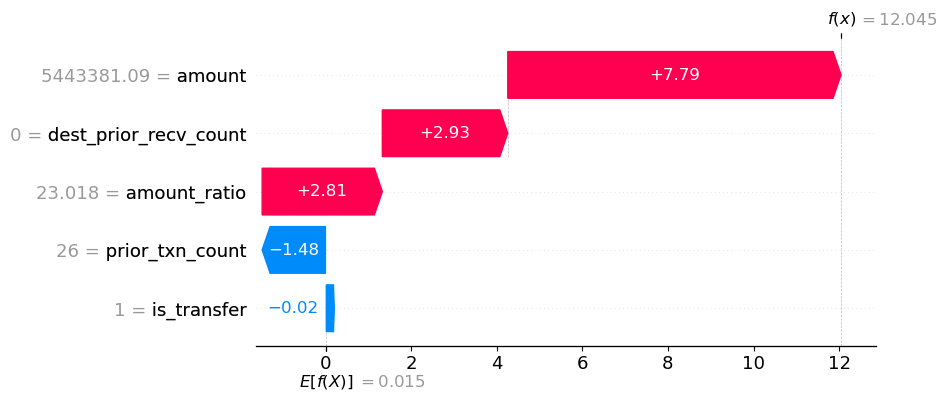

In [191]:
shap.plots.waterfall(shap_values[i])

This was flaged because the transfer was $5.4M, which is a very large amount (+7.79). The recipient has never recieved money before (+2.93) and the amount is far above this sender's usual (+2.81)

In [192]:
false_alarms = np.where(xgb_flags & (y_test == 0).values)[0]
i = false_alarms[0]          # position of the first caught fraud case
X_test_raw.iloc[i]     # look at its actual feature values

amount                   1.792657e+06
is_transfer              1.000000e+00
prior_txn_count          2.220000e+02
amount_ratio             9.825925e+00
dest_prior_recv_count    1.700000e+01
Name: 3399273, dtype: float64

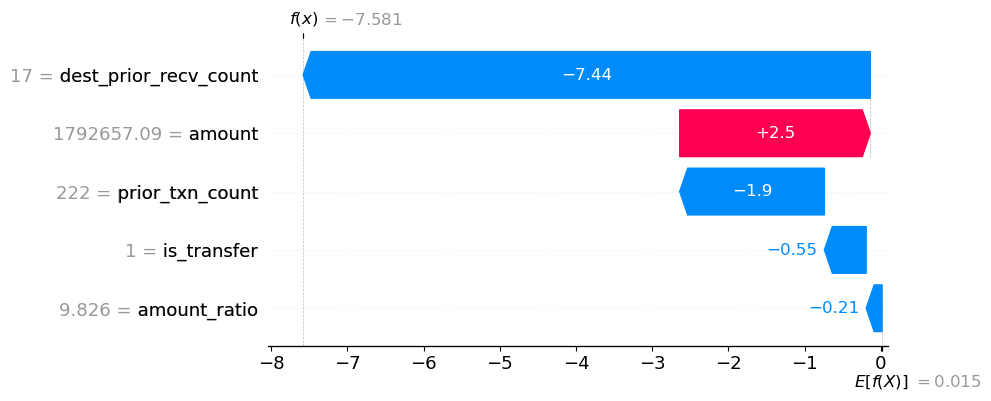

In [193]:
shap.plots.waterfall(shap_values[i])

The model does not think this was a fraud at all, but why was it flagged? Because of the cutoff. The recipient has recieved money 17 times before, an established payee and the strongest push away from fraud. The sender has 222 past transactions, which indicates that it is an established  customer. The amount of $1.79M is the only thing that makes it looks sus. 

In [194]:
xgb_cutoff

np.float32(0.0005019502)

In [195]:
3600000/50

72000.0